# ch198 — Kronecker Products and Structured Matrices

> **Prerequisites:** ch151 (Matrices), ch154 (Matrix Multiplication), ch172 (Diagonalization), ch173 (SVD)
> **You will learn:**
> - What the Kronecker product $A \otimes B$ computes and how it arises
> - The vec() operator and the identity vec(AXB) = (B⊤ ⊗ A) vec(X)
> - Block diagonal and block circulant matrices
> - Separable filters in signal/image processing
> - How structure enables orders-of-magnitude speedups
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

The **Kronecker product** $A \otimes B$ tiles copies of $B$ scaled by entries of $A$ to produce a block matrix. If $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{p \times q}$, then $A \otimes B \in \mathbb{R}^{mp \times nq}$.

Kronecker products arise whenever two independent linear systems act on a combined space — the joint action is the Kronecker product of the individual actions. Examples: 2D image filtering (row filter ⊗ column filter), multi-task learning (task covariance ⊗ feature covariance), and Sylvester matrix equations.

Common misconception: $(A \otimes B)(C \otimes D) = (AC) \otimes (BD)$ only holds when the shapes are compatible for standard matrix multiplication.

## 2. Intuition & Mental Models

**Grid interpretation:** if $A$ describes row interactions and $B$ describes column interactions, $A \otimes B$ describes the combined row-column interaction on a 2D grid — exactly what a separable 2D filter does.

**The vec() operator** stacks matrix columns into a vector. Key identity:
$$\text{vec}(AXB) = (B^\top \otimes A)\,\text{vec}(X)$$
This converts matrix equations to vector equations — turns $AX + XB = C$ (Sylvester equation) into a standard linear system.

**Block diagonal matrices** $(A_1, \ldots, A_k)$ appear when $k$ independent subsystems share a common interface. Each block can be solved independently: total cost $\sum_i O(n_i^3)$ vs $O((\sum_i n_i)^3)$ for the dense case.

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_19440\2745857543.py:28: UserWarning: Glyph 8855 (\N{CIRCLED TIMES}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8855 (\N{CIRCLED TIMES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


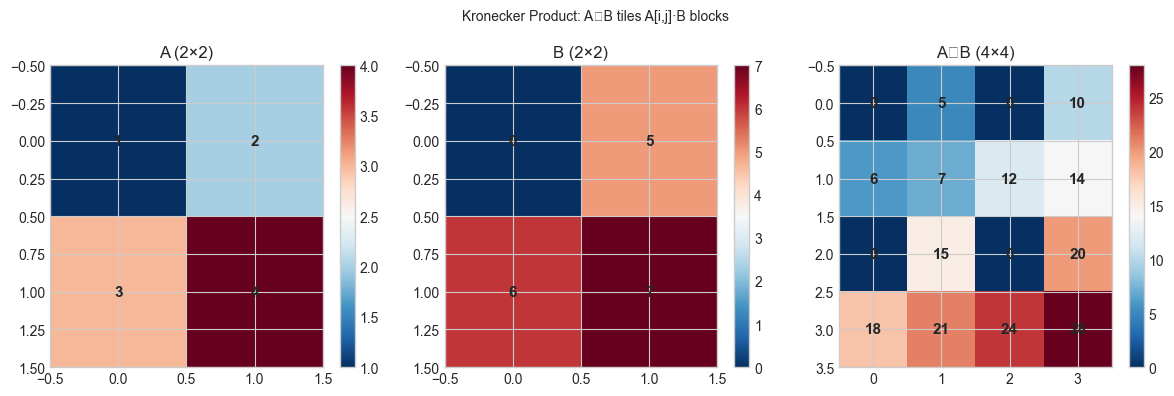

Verify with numpy: True


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

def kron(A, B):
    """Kronecker product A ⊗ B."""
    m, n = A.shape; p, q = B.shape
    C = np.zeros((m*p, n*q))
    for i in range(m):
        for j in range(n):
            C[i*p:(i+1)*p, j*q:(j+1)*q] = A[i,j] * B
    return C

A = np.array([[1.,2.],[3.,4.]])
B = np.array([[0.,5.],[6.,7.]])
K = kron(A, B)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mat, title in [(axes[0],A,'A (2×2)'),(axes[1],B,'B (2×2)'),(axes[2],K,'A⊗B (4×4)')]:
    im = ax.imshow(mat, cmap='RdBu_r', aspect='auto')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j,i,f'{mat[i,j]:.0f}',ha='center',va='center',fontsize=11,fontweight='bold')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.suptitle('Kronecker Product: A⊗B tiles A[i,j]·B blocks', fontsize=10)
plt.tight_layout()
plt.show()
print('Verify with numpy:', np.allclose(K, np.kron(A, B)))

## 4. Mathematical Formulation

**Definition:** $(A \otimes B)_{(i-1)p+k,\,(j-1)q+l} = a_{ij}\, b_{kl}$

**Key algebraic properties:**
- Mixed product: $(A \otimes B)(C \otimes D) = (AC) \otimes (BD)$
- Transpose: $(A \otimes B)^\top = A^\top \otimes B^\top$
- Inverse: $(A \otimes B)^{-1} = A^{-1} \otimes B^{-1}$ (when both exist)
- Eigenvalues: if $A\mathbf{u} = \lambda\mathbf{u}$ and $B\mathbf{v} = \mu\mathbf{v}$, then $(A\otimes B)(\mathbf{u}\otimes\mathbf{v}) = \lambda\mu(\mathbf{u}\otimes\mathbf{v})$

**vec identity** (vectorization):
$$\text{vec}(X) = \text{columns of } X \text{ stacked}, \quad \text{vec}(AXB) = (B^\top \otimes A)\,\text{vec}(X)$$

**Sylvester equation** $AX + XB = C$: using vec identity becomes $(I \otimes A + B^\top \otimes I)\,\text{vec}(X) = \text{vec}(C)$.

## 5. Python Implementation

In [2]:
def vec(X):
    """Stack columns of X into a vector (column-major order)."""
    return X.T.flatten()

def unvec(v, m, n):
    """Inverse vec: reshape to (m, n) matrix."""
    return v.reshape(n, m).T

# Verify vec identity: vec(AXB) = (B.T ⊗ A) @ vec(X)
A_v = rng.normal(0,1,(3,3))
B_v = rng.normal(0,1,(3,3))
X_v = rng.normal(0,1,(3,3))

lhs = vec(A_v @ X_v @ B_v)
rhs = np.kron(B_v.T, A_v) @ vec(X_v)
print(f'vec identity error: {np.linalg.norm(lhs - rhs):.2e}  (should be ~0)')

# Solve Sylvester equation AX + XB = C via Kronecker product
def solve_sylvester(A, B, C):
    """
    Solve AX + XB = C.
    Converts to (I⊗A + B.T⊗I) vec(X) = vec(C).
    """
    n = A.shape[0]
    I = np.eye(n)
    M = np.kron(I, A) + np.kron(B.T, I)
    vec_X = np.linalg.solve(M, vec(C))
    return unvec(vec_X, n, n)

C_v = rng.normal(0,1,(3,3))
X_sol = solve_sylvester(A_v, B_v, C_v)
resid = np.linalg.norm(A_v @ X_sol + X_sol @ B_v - C_v)
print(f'Sylvester residual: {resid:.2e}')

vec identity error: 5.56e-16  (should be ~0)
Sylvester residual: 1.87e-15


## 6. Experiments

C:\Users\user\AppData\Local\Temp\ipykernel_19440\3127294582.py:36: UserWarning: Glyph 8855 (\N{CIRCLED TIMES}) missing from font(s) Arial.
  plt.tight_layout()


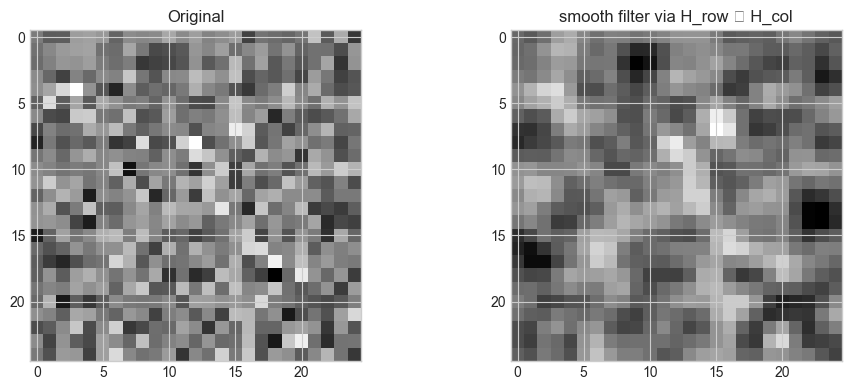

2D filter applied via single Kronecker product: (625, 625) matrix


In [3]:
# --- Experiment: 2D separable convolution via Kronecker product ---
# Hypothesis: (H_row ⊗ H_col) vec(image) = vec(filtered image)
# Try changing: FILTER_TYPE

FILTER_TYPE = 'smooth'  # <-- try 'edge', 'sharpen'

def conv_matrix_1d(h, n):
    C = np.zeros((n, n))
    pad = len(h) // 2
    for i in range(n):
        for ki, hv in enumerate(h):
            j = i + ki - pad
            if 0 <= j < n:
                C[i, j] = hv
    return C

n_img = 25
image = rng.normal(0,1,(n_img,n_img))

if FILTER_TYPE == 'smooth':
    h = np.array([0.25, 0.5, 0.25])
elif FILTER_TYPE == 'edge':
    h = np.array([-1., 0., 1.])
else:
    h = np.array([-1., 5., -1.])

H = conv_matrix_1d(h, n_img)
H_2d = np.kron(H, H)  # separable 2D filter
img_filtered = (H_2d @ image.flatten()).reshape(n_img, n_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(img_filtered, cmap='gray')
axes[1].set_title(f'{FILTER_TYPE} filter via H_row ⊗ H_col')
plt.tight_layout()
plt.show()
print(f'2D filter applied via single Kronecker product: {H_2d.shape} matrix')

## 7. Exercises

**Easy 1.** Compute $I_2 \otimes B$ for a $2\times2$ identity and arbitrary $B$. What is the pattern? What is $A \otimes I_2$?

**Easy 2.** Verify the eigenvalue property: $A \otimes B$ has eigenvalues $\{\lambda_i \mu_j\}$ where $\{\lambda_i\}$ are eigenvalues of $A$ and $\{\mu_j\}$ of $B$. Test with two $3\times3$ symmetric matrices.

**Medium 1.** Implement block-diagonal matrix-vector multiply: given $k$ matrices $A_1, \ldots, A_k$ and a vector $\mathbf{x}$ partitioned accordingly, compute $\text{blkdiag}(A_1,\ldots,A_k)\mathbf{x}$ without forming the full block-diagonal matrix.

**Medium 2.** The Kronecker-factored least squares problem: minimize $\|AXB - C\|_F^2$ over $X$. Use the vec identity to reduce it to a standard least-squares problem and solve.

**Hard.** Build a 3D Laplacian via Kronecker products: $L_{3D} = L \otimes I \otimes I + I \otimes L \otimes I + I \otimes I \otimes L$ where $L$ is the 1D Laplacian. Solve $L_{3D}\mathbf{u} = \mathbf{f}$ on a small 3D grid using the CG method from ch196.

## 8. Mini Project

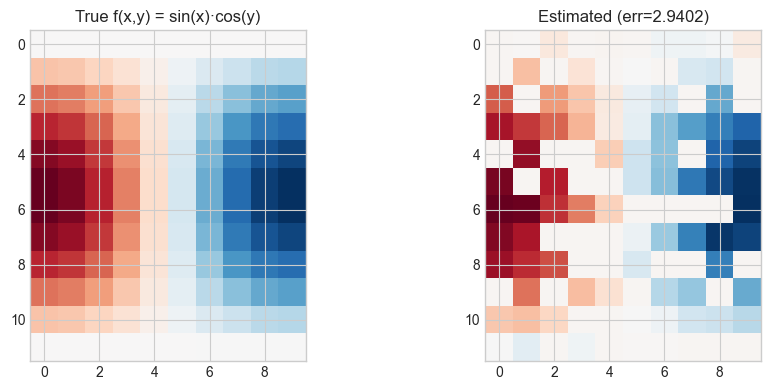

In [4]:
# --- Mini Project: Multi-Dimensional Separable Regression ---
# Fit f(x,y) on a 2D grid using Kronecker-structured design matrix.

NX, NY, N_OBS = 12, 10, 150

a_true = np.sin(np.linspace(0, np.pi, NX))
b_true = np.cos(np.linspace(0, np.pi, NY))
F_true = np.outer(a_true, b_true)

obs_x = rng.integers(0, NX, N_OBS)
obs_y = rng.integers(0, NY, N_OBS)
y_obs = F_true[obs_x, obs_y] + 0.05 * rng.normal(0,1,N_OBS)

# Design matrix: each row is e_x ⊗ e_y (one-hot for grid point)
A_design = np.zeros((N_OBS, NX * NY))
for k, (xi, yi) in enumerate(zip(obs_x, obs_y)):
    A_design[k, xi * NY + yi] = 1.0

F_hat = np.linalg.lstsq(A_design, y_obs, rcond=None)[0].reshape(NX, NY)
err = np.linalg.norm(F_hat - F_true, 'fro')

fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].imshow(F_true, cmap='RdBu_r')
axes[0].set_title('True f(x,y) = sin(x)·cos(y)')
axes[1].imshow(F_hat, cmap='RdBu_r')
axes[1].set_title(f'Estimated (err={err:.4f})')
plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- The Kronecker product $A \otimes B$ encodes the joint action of two independent linear maps; it arises in 2D filtering, multi-task learning, and matrix equations *(ch154)*.
- The vec identity $\text{vec}(AXB) = (B^\top \otimes A)\text{vec}(X)$ converts matrix equations to vector equations, enabling Kronecker-based solvers.
- Separable structure reduces 2D filter application from $O(n^4)$ to $O(n^3)$; 3D reductions are even more dramatic.
- Block diagonal matrices arise in independent subsystems and can be solved block-by-block.

**Forward:** Kronecker structure appears in multi-task Gaussian process regression, tensor decompositions (used in recommender systems at scale), and K-FAC (Kronecker-Factored Approximate Curvature) for efficient neural network optimization. The 3D Laplacian via Kronecker products connects to physics simulation.

**Backward:** This generalizes ch154 (Matrix Multiplication) to block-structured settings and applies ch172 (Diagonalization) — the eigenvalue product property $(\lambda_i \mu_j)$ follows directly from diagonalizing both $A$ and $B$ simultaneously.